# ChatBot Using LangGraph

In [3]:
pip install langchain-google-genai

Note: you may need to restart the kernel to use updated packages.


In [4]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GOOGLE_API_KEY")

In [5]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import BaseMessage,add_messages
from langchain_core.messages import HumanMessage,AIMessage
from typing import Annotated,TypedDict,Literal
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver


load_dotenv()
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash",google_api_key=secret_value_0)

class ChatBotState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

def ChatBot_Node(state:ChatBotState)->ChatBotState:
    message=state["messages"]
    response=llm.invoke(message).content
    return {"messages":[response]}

graph=StateGraph(ChatBotState)
graph.add_node("ChatBotNode",ChatBot_Node)

graph.add_edge(START,"ChatBotNode")
graph.add_edge("ChatBotNode",END)

#workflow=graph.compile()
# initial_state={
#     "messages":"Hi"
# }
# result=workflow.invoke(initial_state)
# print(result["messages"][-1].content)


checkpointer=MemorySaver()

chatbot=graph.compile(checkpointer=checkpointer)

thread_id="1"

config={
    "configurable":{
        "thread_id":thread_id
    }
}

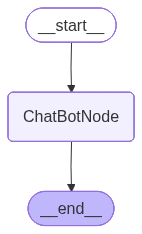

In [6]:
chatbot

In [ ]:
while True:
    user_input=input("User:")
    if user_input== "quit" or user_input=="exit":
        print("Goodbye,Take care.")
        break
    else:
        initial_state={"messages":[HumanMessage(content=user_input)]}
        result=chatbot.invoke(initial_state,config=config)
        print("AI:",result["messages"][-1].content)